# CSC8628 — U2OS Nuclei Segmentation
**Module:** CSC8628 Image Processing | **Dataset:** Microscopy Dataset

This notebook implements a **classical** (non-deep-learning) segmentation pipeline, built up in **four stages** so the improvement at each step is measurable and explainable.




## Section 0 — Colab Pro+ setup & runtime

The libraries below (`scikit-image`, `scipy`, `numpy`, `pandas`, `matplotlib`, `tifffile`) ship with Colab. The next cell just confirms they import; it pip-installs `tifffile` only if missing.

In [1]:
import sys, subprocess
def ensure(pkg, imp=None):
    try: __import__(imp or pkg)
    except ImportError: subprocess.run([sys.executable,"-m","pip","install","-q",pkg])
ensure("tifffile")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tifffile
from PIL import Image
from scipy import ndimage as ndi
import skimage
from skimage.filters import threshold_otsu, threshold_local, gaussian
from skimage.morphology import remove_small_objects, binary_opening, disk
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.measure import label, regionprops
from skimage.color import label2rgb
from skimage import exposure
print("scikit-image", skimage.__version__, "| all imports OK")

scikit-image 0.25.2 | all imports OK


## Section 1 — Mount Google Drive & set paths

```
/content/drive/MyDrive/Microscopy_Data/
        im/   ← *.tif  (input images)
        gt/   ← *.png  (ground-truth masks)
```
Run the next cell, click the auth pop-up, and allow access.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob
ROOT   = "/content/drive/MyDrive/Microscopy_Data"
IM_DIR = os.path.join(ROOT, "im")
GT_DIR = os.path.join(ROOT, "gt")
OUT_DIR= os.path.join(ROOT, "outputs"); os.makedirs(OUT_DIR, exist_ok=True)


def stem(p): return os.path.splitext(os.path.basename(p))[0]
im_files = {stem(p): p for p in glob.glob(os.path.join(IM_DIR, "*.tif")) +
                              glob.glob(os.path.join(IM_DIR, "*.tiff"))}
gt_files = {stem(p): p for p in glob.glob(os.path.join(GT_DIR, "*.png"))}
pairs = sorted(set(im_files) & set(gt_files))
print(f"Images found : {len(im_files)}")
print(f"Masks found  : {len(gt_files)}")
print(f"Matched pairs: {len(pairs)}")
assert len(pairs) > 0, "No matched pairs. Check ROOT path and that im/ and gt/ stems match."
print("Example pair:", pairs[0])

Mounted at /content/drive
Images found : 5
Masks found  : 5
Matched pairs: 5
Example pair: IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB


## Section 2 — VERIFY THE GROUND TRUTH

A ground-truth mask must be a label image: background = 0, and each nucleus a positive value. If it loads as a 3-channel RGB image with only a handful of values (e.g. 0–5), it has been corrupted (often by lossy re-compression) and **any metric you compute will be meaningless**.

This cell loads one pair, prints what the mask actually contains, and shows the image, the binarised mask, and their overlay so you can confirm they line up. Read the printed **VERDICT**.

Image : shape=(520, 696), dtype=uint16, range [120, 4095]
Mask  : raw shape=(520, 696, 4) -> 2D | type=BINARY | objects=94 | foreground=19.53%
Align : mean intensity inside mask=599 vs background=163 (nuclei are 3.68x brighter)

VERDICT: ✅ VALID ground truth — mask aligns with the nuclei. Proceed.


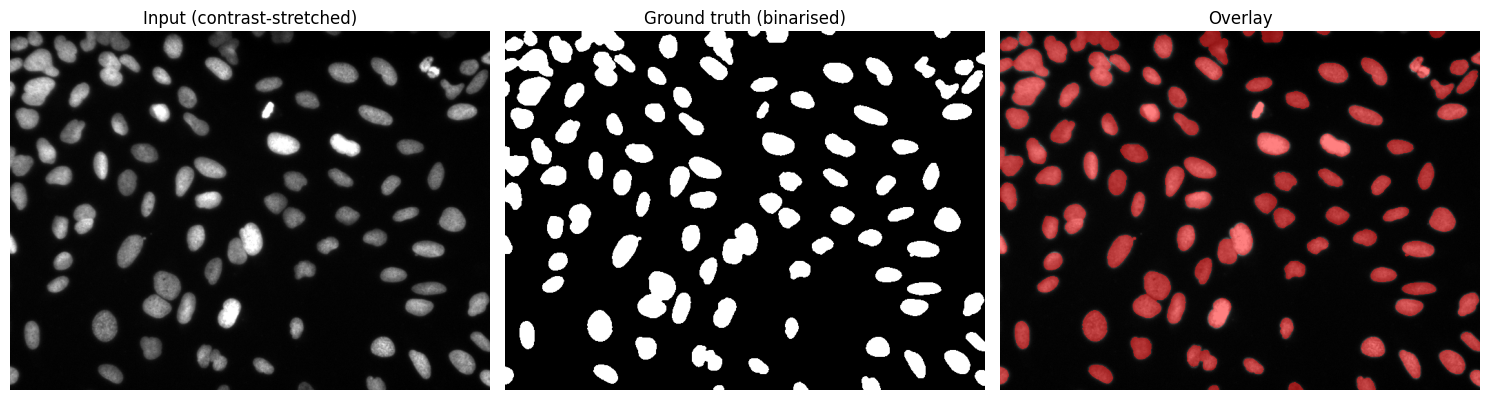

In [3]:
def load_image(path):
    """Read a 16-bit microscopy TIFF as a 2-D array."""
    img = tifffile.imread(path)
    if img.ndim == 3: img = img[..., 0]
    return img

def load_mask(path):
    """Return a 2-D mask. Drops alpha and collapses RGB so it works whether the
    mask is grayscale, binary-in-RGB, or RGBA. Background must be 0."""
    m = np.array(Image.open(path))
    if m.ndim == 3:
        m = m[..., :3].max(axis=-1)   # ignore alpha channel; combine R,G,B
    return m

def stretch(img, lo=1, hi=99.5):
    a, b = np.percentile(img, lo), np.percentile(img, hi)
    return exposure.rescale_intensity(img.astype(np.float32), in_range=(a, b), out_range=(0, 1))

# --- verify one pair ---
k = pairs[0]
img = load_image(im_files[k]); m = load_mask(gt_files[k])
raw = np.array(Image.open(gt_files[k]))
fg = m > 0
uniq = np.unique(m)
n_obj = ndi.label(fg)[1]
fg_frac = fg.mean()
in_mean  = img[fg].mean() if fg.any() else 0.0      # intensity inside the mask
out_mean = img[~fg].mean()                           # intensity outside (background)
ratio = in_mean / (out_mean + 1e-8)
mask_type = "INSTANCE-labelled" if len(uniq) > 20 else "BINARY"

print(f"Image : shape={img.shape}, dtype={img.dtype}, range [{img.min()}, {img.max()}]")
print(f"Mask  : raw shape={raw.shape} -> 2D | type={mask_type} | objects={n_obj} | "
      f"foreground={100*fg_frac:.2f}%")
print(f"Align : mean intensity inside mask={in_mean:.0f} vs background={out_mean:.0f} "
      f"(nuclei are {ratio:.2f}x brighter)")

# Valid GT = sane foreground fraction, several objects, and foreground that sits on bright nuclei
valid = (0.005 < fg_frac < 0.60) and (n_obj >= 3) and (ratio > 1.2)
print("\nVERDICT:",
      "✅ VALID ground truth — mask aligns with the nuclei. Proceed."
      if valid else
      "❌ Foreground does not align with bright nuclei — check your masks.")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(stretch(img), cmap="gray"); ax[0].set_title("Input (contrast-stretched)")
ax[1].imshow(fg, cmap="gray");           ax[1].set_title("Ground truth (binarised)")
ax[2].imshow(stretch(img), cmap="gray")
ax[2].imshow(np.ma.masked_where(~fg, fg), cmap="autumn", alpha=0.5)
ax[2].set_title("Overlay")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## Section 3 — Load the full dataset into memory

We store every image and its mask once, so the evaluation loop is fast. For metrics we treat the task as **semantic** segmentation (nucleus vs. background), so masks are binarised with `mask > 0`. (The instance IDs are kept available for the object-level extension in Section 6.)

In [4]:
images = [load_image(im_files[k]) for k in pairs]
masks  = [load_mask(gt_files[k])  for k in pairs]   # label images (0 = background)
gts    = [(m > 0) for m in masks]                   # binary ground truth
print(f"Loaded {len(images)} image/mask pairs.")

Loaded 5 image/mask pairs.


## Section 4 — Evaluation metrics

For a binary prediction vs. binary ground truth we count pixels:
TP (correct nucleus), FP (false nucleus), FN (missed nucleus), TN (correct background).

- **IoU (Jaccard), foreground:** TP / (TP + FP + FN) — the honest measure of nucleus overlap.
- **IoU, background:** TN / (TN + FP + FN).
- **mIoU:** mean of the two class IoUs (this is what the brief names).
- **Dice (F1):** 2·TP / (2·TP + FP + FN).
- **Sensitivity / Specificity** as defined below.

**Analysis point worth marks:** nuclei occupy only ~1–6 % of pixels, so background IoU is ~0.97 and *inflates* mIoU. Always report **foreground IoU and Dice** as the real headline numbers and explain this imbalance in your Discussion — that demonstrates you understand the metric rather than hiding behind it.

In [5]:
def metrics(pred, gt):
    pred = pred.astype(bool); gt = gt.astype(bool)
    TP = np.logical_and(pred, gt).sum()
    FP = np.logical_and(pred, ~gt).sum()
    FN = np.logical_and(~pred, gt).sum()
    TN = np.logical_and(~pred, ~gt).sum()
    eps = 1e-8
    iou_fg = TP / (TP + FP + FN + eps)
    iou_bg = TN / (TN + FP + FN + eps)
    return {
        "IoU_fg": iou_fg,
        "IoU_bg": iou_bg,
        "mIoU":   (iou_fg + iou_bg) / 2,
        "Dice":   2*TP / (2*TP + FP + FN + eps),
        "Sensitivity": TP / (TP + FN + eps),
        "Specificity": TN / (TN + FP + eps),
    }

## Section 5 — The segmentation pipeline (Stages 1–4)

Workflow: **pre-process → threshold → clean → split touching nuclei → refine.**
```
16-bit image → normalise + Gaussian smooth → threshold (Otsu / adaptive)
   → morphological cleanup + remove small objects + fill holes
   → distance transform → seed detection → watershed (split clusters)
   → instance labels  →  binarise for metrics
```


### Stage 1 — Baseline: global Otsu threshold
The simplest classical segmenter. We normalise the 16-bit image to [0,1], blur slightly to suppress noise and internal nuclear texture (prevents over-segmentation later), then split foreground/background with a single global threshold chosen by **Otsu's method** (maximises between-class variance; Otsu, 1979).

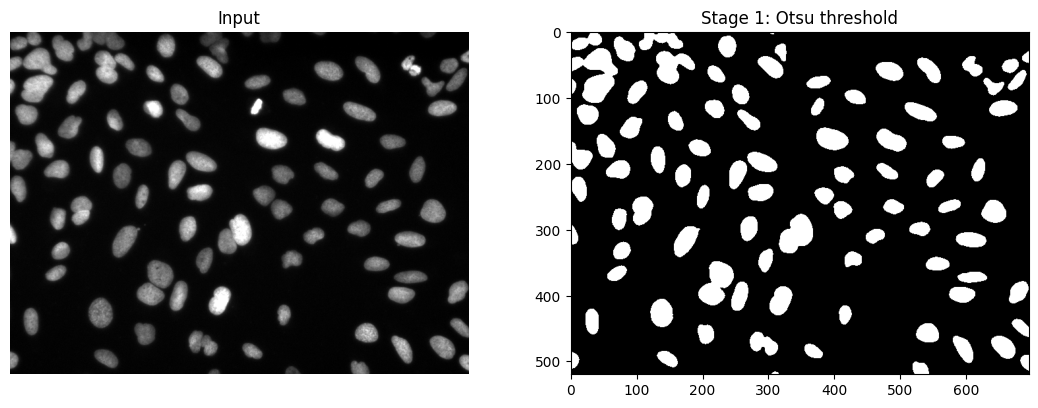

<Figure size 640x480 with 0 Axes>

In [6]:
def preprocess(img16, sigma=1.5):
    img = img16.astype(np.float32)
    lo, hi = np.percentile(img, 1), np.percentile(img, 99.5)
    img = np.clip((img - lo) / (hi - lo + 1e-8), 0, 1)
    return gaussian(img, sigma=sigma)

def stage1_baseline(img16):
    img = preprocess(img16)
    return img > threshold_otsu(img)

# Visual check on one image
ex = images[0]
b1 = stage1_baseline(ex)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(stretch(ex), cmap="gray"); ax[0].set_title("Input")
ax[1].imshow(b1, cmap="gray");          ax[1].set_title("Stage 1: Otsu threshold")
for a in ax: a.axis("off"); plt.tight_layout(); plt.show()

### Stage 2 — Morphological cleanup
Thresholding leaves speckle noise and pinholes. We apply a morphological **opening** (removes tiny false objects), **fill holes** inside nuclei, and **remove small objects** below a pixel-area threshold. This raises precision without changing the core detection.

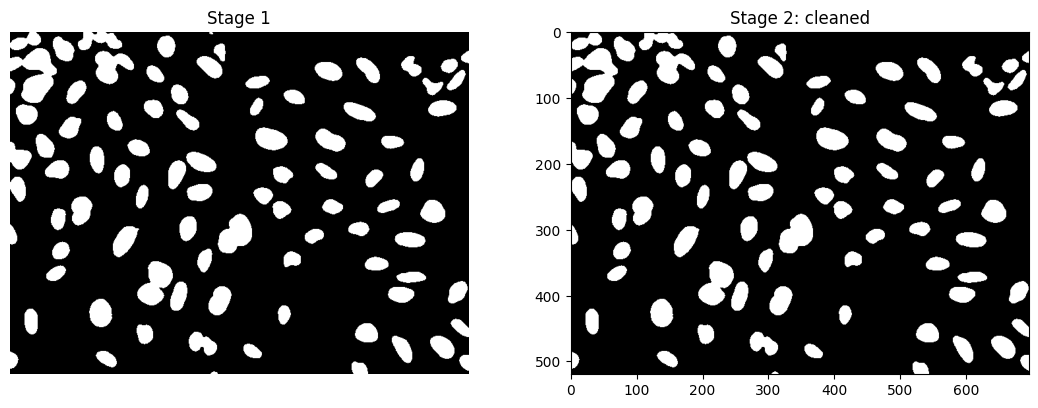

<Figure size 640x480 with 0 Axes>

In [7]:
def stage2_cleanup(img16, min_size=30):
    b = stage1_baseline(img16)
    b = binary_opening(b, disk(2))
    b = ndi.binary_fill_holes(b)
    b = remove_small_objects(b, min_size=min_size)
    return b

b2 = stage2_cleanup(ex)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(b1, cmap="gray"); ax[0].set_title("Stage 1")
ax[1].imshow(b2, cmap="gray"); ax[1].set_title("Stage 2: cleaned")
for a in ax: a.axis("off"); plt.tight_layout(); plt.show()

### Stage 3 — Split touching nuclei (distance transform + watershed)
The key improvement. Adjacent nuclei merge into one blob under thresholding. We compute the **Euclidean distance transform** of the binary mask (each foreground pixel = distance to nearest background), find **local maxima** as one seed per nucleus, then run a **marker-controlled watershed** on the inverted distance map. This "floods" basins from the seeds and draws ridge lines between touching nuclei (Vincent & Soille, 1991). Output is an **instance** label image.

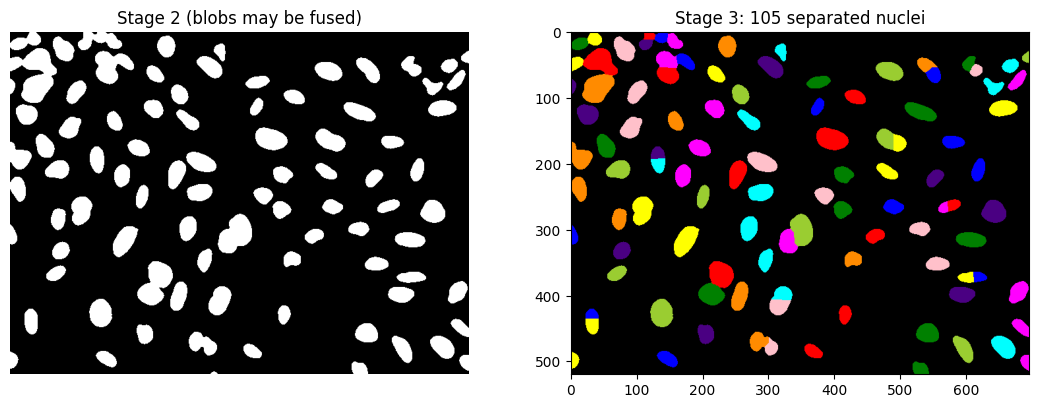

<Figure size 640x480 with 0 Axes>

In [8]:
def stage3_watershed(img16, min_size=30, min_distance=7):
    b = stage2_cleanup(img16, min_size)
    distance = ndi.distance_transform_edt(b)
    coords = peak_local_max(distance, min_distance=min_distance, labels=b)
    seeds = np.zeros(distance.shape, dtype=bool)
    if len(coords): seeds[tuple(coords.T)] = True
    markers, _ = ndi.label(seeds)
    labels_ws = watershed(-distance, markers, mask=b)
    return labels_ws  # instance labels; use (>0) for binary metrics

lab3 = stage3_watershed(ex)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(b2, cmap="gray"); ax[0].set_title("Stage 2 (blobs may be fused)")
ax[1].imshow(label2rgb(lab3, bg_label=0)); ax[1].set_title(f"Stage 3: {lab3.max()} separated nuclei")
for a in ax: a.axis("off"); plt.tight_layout(); plt.show()

### Stage 4 — Refinement: adaptive thresholding + tuning
A single global threshold misses **dim nuclei** when illumination is uneven. We replace it with a **local (adaptive) threshold** that adapts to each neighbourhood, gated by a global floor so background noise is not promoted to foreground. Then the same cleanup and watershed. Tune `block_size`, `min_size`, `min_distance` and `sigma` and report the effect.

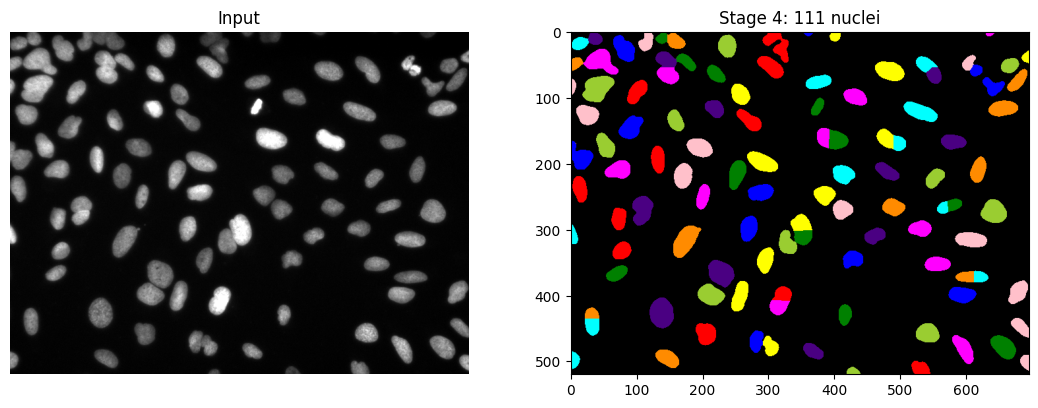

<Figure size 640x480 with 0 Axes>

In [9]:
def stage4_refined(img16, block_size=51, min_size=30, min_distance=7, sigma=1.5, floor_frac=0.6):
    img = preprocess(img16, sigma=sigma)
    floor = threshold_otsu(img) * floor_frac
    local_t = threshold_local(img, block_size=block_size)
    b = (img > local_t) & (img > floor)
    b = binary_opening(b, disk(2))
    b = ndi.binary_fill_holes(b)
    b = remove_small_objects(b, min_size=min_size)
    distance = ndi.distance_transform_edt(b)
    coords = peak_local_max(distance, min_distance=min_distance, labels=b)
    seeds = np.zeros(distance.shape, dtype=bool)
    if len(coords): seeds[tuple(coords.T)] = True
    markers, _ = ndi.label(seeds)
    return watershed(-distance, markers, mask=b)

lab4 = stage4_refined(ex)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(stretch(ex), cmap="gray"); ax[0].set_title("Input")
ax[1].imshow(label2rgb(lab4, bg_label=0)); ax[1].set_title(f"Stage 4: {lab4.max()} nuclei")
for a in ax: a.axis("off"); plt.tight_layout(); plt.show()

## Section 6 — Quantitative results (Tasks 2 & 3)
Run every stage on every image, collect metrics, and present a table + a graph showing the metric improving across stages.

In [10]:
STAGES = {
    "S1: Otsu":        lambda im: stage1_baseline(im),
    "S2: + cleanup":   lambda im: stage2_cleanup(im),
    "S3: + watershed": lambda im: stage3_watershed(im) > 0,
    "S4: + adaptive":  lambda im: stage4_refined(im) > 0,
}

rows = []
for k, img, gt in zip(pairs, images, gts):
    for sname, fn in STAGES.items():
        m = metrics(fn(img), gt)
        m.update(image=k[:12], stage=sname)
        rows.append(m)
df = pd.DataFrame(rows)

summary = df.groupby("stage")[["IoU_fg","mIoU","Dice","Sensitivity","Specificity"]].mean().round(3)
summary = summary.reindex(list(STAGES.keys()))
print("Mean metrics across all images (per stage):\n")
print(summary)

Mean metrics across all images (per stage):

                 IoU_fg   mIoU   Dice  Sensitivity  Specificity
stage                                                          
S1: Otsu          0.887  0.930  0.940        0.907        0.996
S2: + cleanup     0.885  0.929  0.939        0.904        0.996
S3: + watershed   0.884  0.928  0.938        0.904        0.996
S4: + adaptive    0.909  0.944  0.952        0.950        0.991


In [11]:
# Per-image foreground IoU table (Task 3)
pivot = df.pivot_table(index="image", columns="stage", values="IoU_fg").round(3)
pivot = pivot.reindex(columns=list(STAGES.keys()))
print("Per-image foreground IoU:\n"); print(pivot)

Per-image foreground IoU:

stage         S1: Otsu  S2: + cleanup  S3: + watershed  S4: + adaptive
image                                                                 
IXMtest_A02_     0.874          0.872            0.872           0.918
IXMtest_A06_     0.927          0.926            0.926           0.919
IXMtest_A09_     0.861          0.860            0.859           0.900
IXMtest_A12_     0.885          0.881            0.881           0.891
IXMtest_A15_     0.886          0.885            0.883           0.916


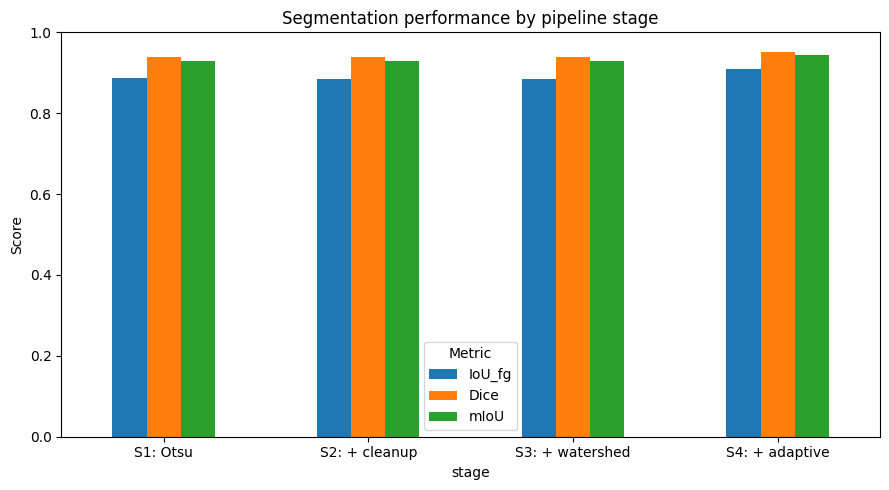

In [12]:
# Bar chart: how the headline metrics improve across stages (Task 3 graph)
ax = summary[["IoU_fg","Dice","mIoU"]].plot(kind="bar", figsize=(9,5), rot=0)
ax.set_ylabel("Score"); ax.set_ylim(0,1)
ax.set_title("Segmentation performance by pipeline stage")
ax.legend(title="Metric"); plt.tight_layout(); plt.show()

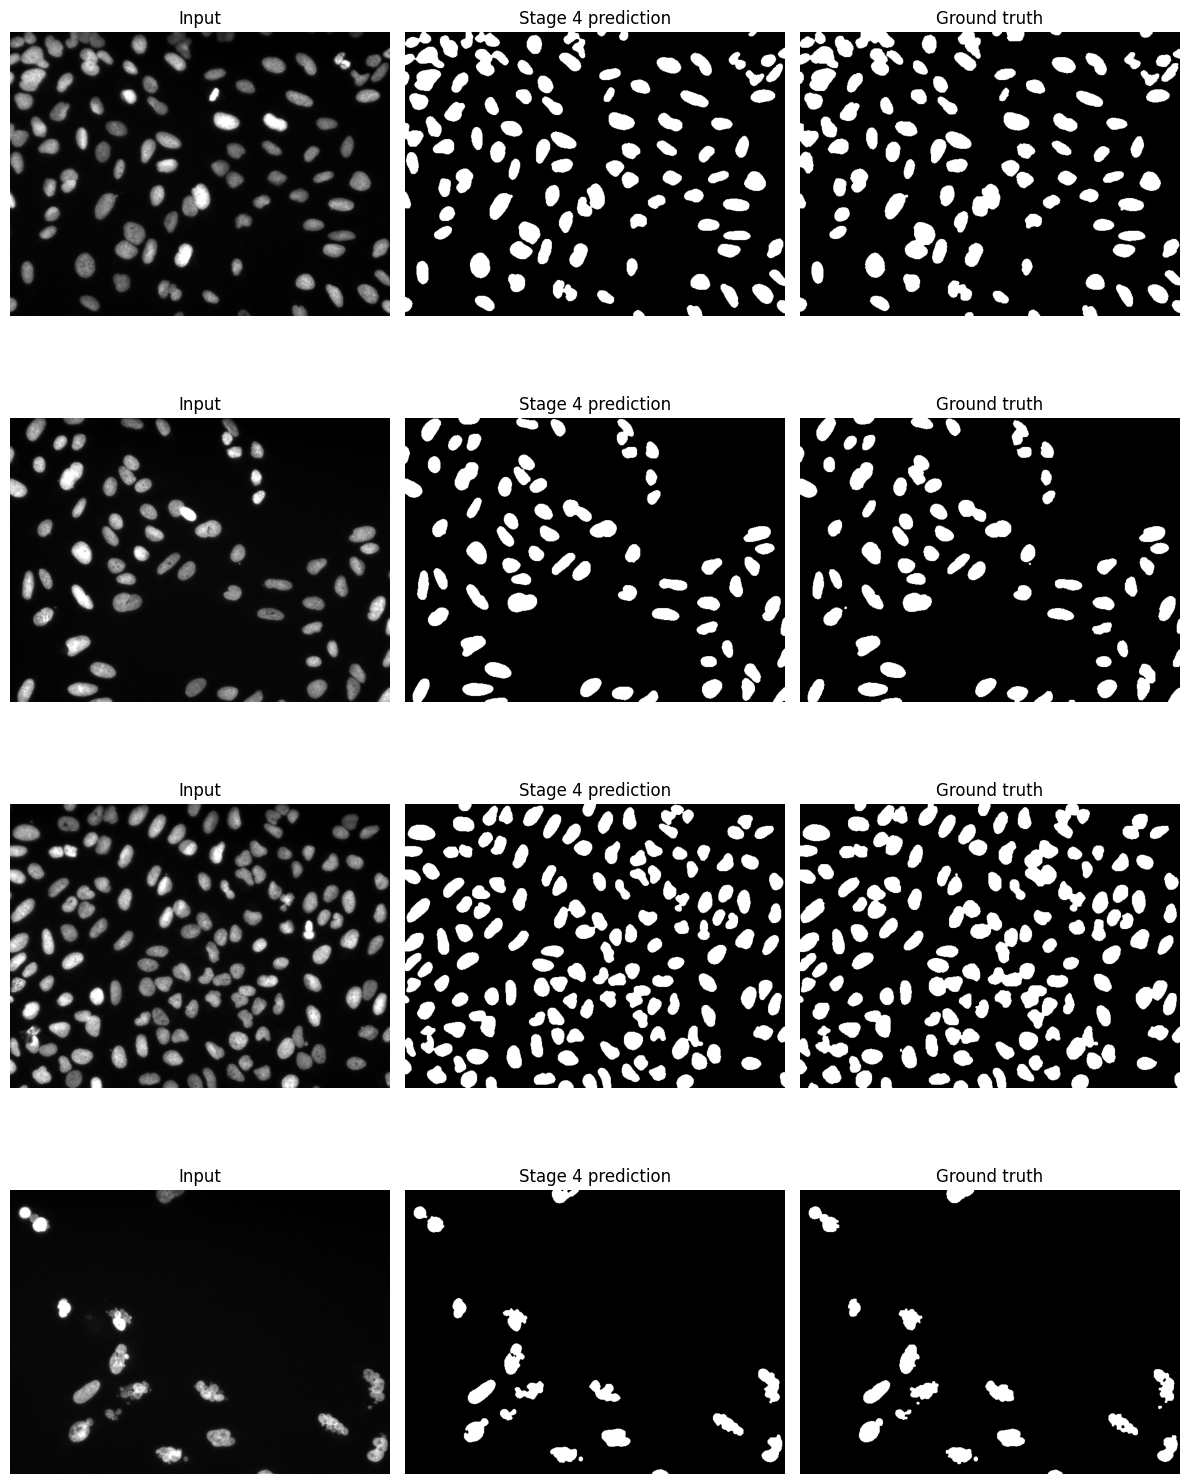

In [13]:
# Qualitative panels: input | prediction | ground truth (Task 3 sample images)
n = min(4, len(pairs))
fig, ax = plt.subplots(n, 3, figsize=(12, 4*n))
if n == 1: ax = ax[None, :]
for i in range(n):
    img, gt = images[i], gts[i]
    pred = stage4_refined(img) > 0
    ax[i,0].imshow(stretch(img), cmap="gray"); ax[i,0].set_title("Input")
    ax[i,1].imshow(pred, cmap="gray");         ax[i,1].set_title("Stage 4 prediction")
    ax[i,2].imshow(gt, cmap="gray");           ax[i,2].set_title("Ground truth")
    for j in range(3): ax[i,j].axis("off")
plt.tight_layout(); plt.show()

### Object-level evaluation and save to Drive
Pixel mIoU rewards big correct regions but ignores whether you counted the *right number of nuclei*. Because Stage 3/4 produce instances, you can match predicted objects to GT objects at IoU > 0.5 and report object **precision / recall / F1**.

In [14]:
def object_f1(pred_lab, gt_lab, iou_thr=0.5):
    gt_ids   = [i for i in np.unique(gt_lab)   if i != 0]
    pred_ids = [i for i in np.unique(pred_lab) if i != 0]
    matched = 0; used = set()
    for g in gt_ids:
        gmask = gt_lab == g; best = 0; best_p = None
        for p in pred_ids:
            if p in used: continue
            pmask = pred_lab == p
            inter = np.logical_and(gmask, pmask).sum()
            if inter == 0: continue
            union = np.logical_or(gmask, pmask).sum()
            iou = inter / union
            if iou > best: best, best_p = iou, p
        if best >= iou_thr and best_p is not None:
            matched += 1; used.add(best_p)
    TP = matched; FP = len(pred_ids) - matched; FN = len(gt_ids) - matched
    eps = 1e-8
    prec = TP/(TP+FP+eps); rec = TP/(TP+FN+eps)
    return dict(obj_precision=prec, obj_recall=rec, obj_F1=2*prec*rec/(prec+rec+eps),
                n_pred=len(pred_ids), n_gt=len(gt_ids))


gt_instances = ndi.label(masks[0] > 0)[0]
print(object_f1(stage4_refined(images[0]), gt_instances))

{'obj_precision': 0.7387387386721858, 'obj_recall': 0.8723404254391128, 'obj_F1': 0.7999999949563357, 'n_pred': 111, 'n_gt': 94}


In [15]:
df.to_csv(os.path.join(OUT_DIR, "metrics_all.csv"), index=False)
summary.to_csv(os.path.join(OUT_DIR, "metrics_summary.csv"))

# re-save the bar chart as a file
ax = summary[["IoU_fg","Dice","mIoU"]].plot(kind="bar", figsize=(9,5), rot=0)
ax.set_ylabel("Score"); ax.set_ylim(0,1); ax.set_title("Performance by stage")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"performance_by_stage.png"), dpi=150); plt.close()
print("Saved CSVs and figure to:", OUT_DIR)

Saved CSVs and figure to: /content/drive/MyDrive/Microscopy_Data/outputs
